# Librerie utili

In [ ]:
%pip install -q -U keras-tuner

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\Antonio\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip' command.


In [5]:
import os
import pickle

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfds
import keras_tuner as kt

from keras import layers, models, optimizers
from keras.models import load_model

from google.colab import files

ModuleNotFoundError: No module named 'tensorflow_datasets'

# Load dati
Il dataset d'interesse è stanford_dogs, contenente 20580 immagini di cani di 120 razze diverse.
L'obiettivo è costruire un modello che classifichi la razza dei cani raffigurati.

In [ ]:
dataset, info = tfds.load(
    'stanford_dogs',
    with_info=True,
    as_supervised=True)

train, test = dataset['train'], dataset['test']
len(train), len(test)

(12000, 8580)

# Visualizzazione di alcuni dati

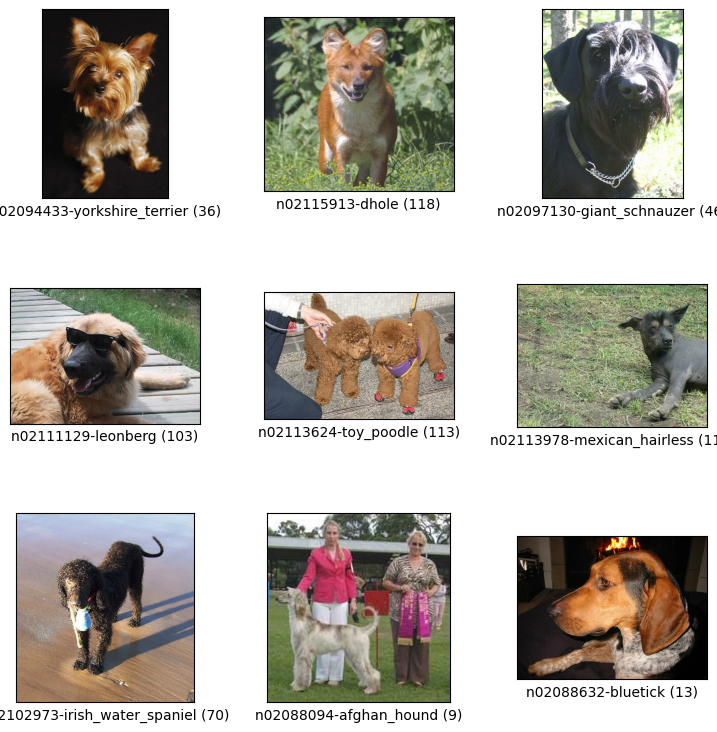

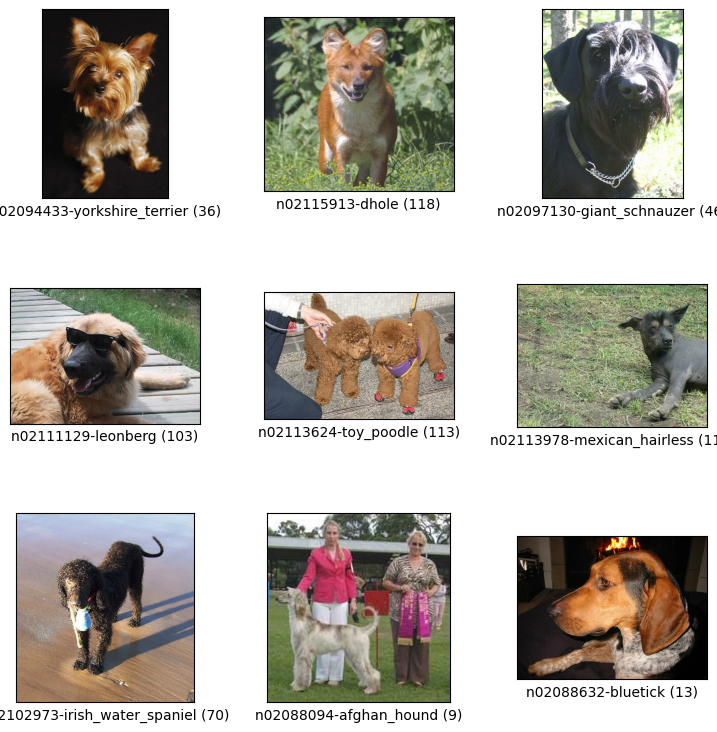

In [ ]:
tfds.visualization.show_examples(dataset['train'], info)

# Preprocessing immagini
Normalizzazione dei pixel da 0 a 256 a una scala da 0 a 1.

Ridimensionamento delle dimensioni in pixel delle immagini, si passa da dimensioni varie a una dimensione unica 224x224 per tutte le immagini.

Batching

In [ ]:
IMG_SIZE = 224 # numero di pixel per asse

def preprocess(image, label):
    """Preprocessa le immagini per il modello"""
    image = tf.cast(image, tf.float32) / 255.0  # Normalizzazione
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])  # Ridimensionamento
    return image, label

# Prepara i dataset
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
# Applicazione del preprocessing
train_dataset = train.map(preprocess, num_parallel_calls=AUTOTUNE)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(AUTOTUNE)

test_dataset = test.map(preprocess, num_parallel_calls=AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

# Esplorative, numero di batch del training set e test set
print("Training set:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Test set:", tf.data.experimental.cardinality(test_dataset).numpy())

# verifica se i valori dei pixel sono stati normalizzati tra 0 e 1
for images, _ in train_dataset.take(1):
    print("Min pixel value:", np.min(images.numpy()))
    print("Max pixel value:", np.max(images.numpy()))

# Prende un batch dal dataset e ne mostra la dimensione
for image, label in train_dataset.take(1):
    print("Dimensione dell'immagine:", image.shape)
    print("Etichetta:", label.shape)

Training set: 375
Test set: 269
Min pixel value: 0.0
Max pixel value: 1.0
Dimensione dell'immagine: (32, 224, 224, 3)
Etichetta: (32,)


#1) Creazione del primo modello (overfittato)

In [ ]:
model = models.Sequential()
#Primo strato convoluzionale
model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                        input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(layers.MaxPooling2D((2, 2)))
#Secondo strato convoluzionale
model.add(layers.Conv2D(64, (3, 3), activation='relu',padding='same'))
model.add(layers.MaxPooling2D((2, 2)))
#terzo strato convoluzionale
model.add(layers.Conv2D(128, (3, 3), activation='relu',padding='same'))
model.add(layers.MaxPooling2D((2, 2)))
#quarto strato convoluzionale
model.add(layers.Conv2D(128, (3, 3), activation='relu',padding='same'))
model.add(layers.MaxPooling2D((2, 2)))
# Appiattisci per la parte completamente connessa
model.add(layers.Flatten())
#strato denso
model.add(layers.Dense(512, activation='relu'))
#strato di output
model.add(layers.Dense(120, activation='softmax')) # funzione di attivazione per multi-classe

model.compile(optimizer="adam", #learning rate default=0.001
              loss="sparse_categorical_crossentropy", # per etichette intere
              metrics=['accuracy'])

model.summary()

history = model.fit(
    train_dataset,
    epochs=10,
)

Test del modello



In [ ]:
test_loss, test_acc=model.evaluate(test_dataset)
print('Test accuracy:', test_acc)

L'accuratezza nel training set dopo 10 epoche è ∼79%, l'accuratezza nel test set è ∼5%. Notevole overfitting

GRAFICI BONTA' DI ADATTAMENTO

In [ ]:
acc = history.history['accuracy']
loss = history.history['loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'b', label='Training acc')
plt.axhline(y=test_acc, color='g', linestyle='--', label=f'Test Accuracy: {test_acc:.2f}')
plt.title('Training accuracy')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'b', label='Training loss')
plt.axhline(y=test_loss, color='r', linestyle='--', label=f'Test Loss: {test_loss:.2f}')
plt.title('Training loss')
plt.legend()
plt.show()

# Creazione del validation set

In [ ]:
# Numero totale di esempi nel test
num_test_examples = info.splits['test'].num_examples

# Percentuale di dati da usare per la validazione, prendendoli dal test set
validation_split = 0.5
num_validation_examples = int(num_test_examples * validation_split)

# Preparo il dataset di validazione e test. Divido il test set in validation set e test set
validation_set = test.take(num_validation_examples)
test_set = test.skip(num_validation_examples)

# Mapping dei dataset
test_dataset = test_set.map(preprocess, num_parallel_calls=AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

validation_dataset = validation_set.map(preprocess, num_parallel_calls=AUTOTUNE)
validation_dataset = validation_dataset.batch(BATCH_SIZE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)

# Controlla le dimensioni
print("Training set:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation set:", tf.data.experimental.cardinality(validation_dataset).numpy())
print("Test set:", tf.data.experimental.cardinality(test_dataset).numpy())

for image, label in test_dataset.take(1):
    print("Dimensione dell'immagine:", image.shape)
    print("Etichetta:", label.shape)

for image, label in validation_dataset.take(1):
    print("Dimensione dell'immagine:", image.shape)
    print("Etichetta:", label.shape)

Training set: 375
Validation set: 135
Test set: 135
Dimensione dell'immagine: (32, 224, 224, 3)
Etichetta: (32,)
Dimensione dell'immagine: (32, 224, 224, 3)
Etichetta: (32,)


#2) Creazione del secondo modello con overfitting

In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu',padding="same",
                        input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu',padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu',padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu',padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())

model.add(layers.Dense(512, activation='relu'))

model.add(layers.Dense(120, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


tenendo il learning rate a 0.001:

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer=optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=['accuracy'])
model.summary()

#Training
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_dataset
)
#Adattamento nel test set
test_loss, test_acc=model.evaluate(test_dataset)
print('Test accuracy:', test_acc)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 14, 14, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 14, 14, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │              

 Total params: 27,856,184 (106.26 MB)

 Trainable params: 27,851,128 (106.24 MB)

 Non-trainable params: 5,056 (19.75 KB)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 90s 208ms/step - accuracy: 0.0172 - loss: 5.4178 - val_accuracy: 0.0214 - val_loss: 5.3289
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 76s 201ms/step - accuracy: 0.0307 - loss: 4.8082 - val_accuracy: 0.0415 - val_loss: 4.5470
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 79s 210ms/step - accuracy: 0.0399 - loss: 4.5789 - val_accuracy: 0.0331 - val_loss: 4.6826
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 213ms/step - accuracy: 0.0499 - loss: 4.4237 - val_accuracy: 0.0557 - val_loss: 4.4073
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 79s 211ms/step - accuracy: 0.0586 - loss: 4.2796 - val_accuracy: 0.0788 - val_loss: 4.1227
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 74s 197ms/step - accuracy: 0.0673 - loss: 4.1707 - val_accuracy: 0.0709 - val_loss: 4.2538
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 75s 199ms/step - accuracy: 0.0859 - loss: 4.0422 - val_accuracy: 0.0690 - val_loss: 4.2174
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 79s 210ms/step - accuracy: 0.0977 - loss: 3

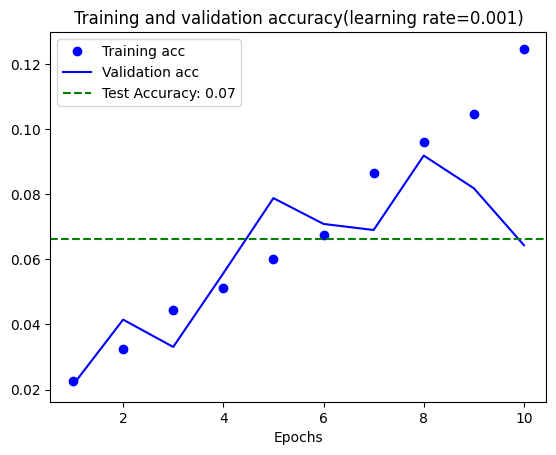

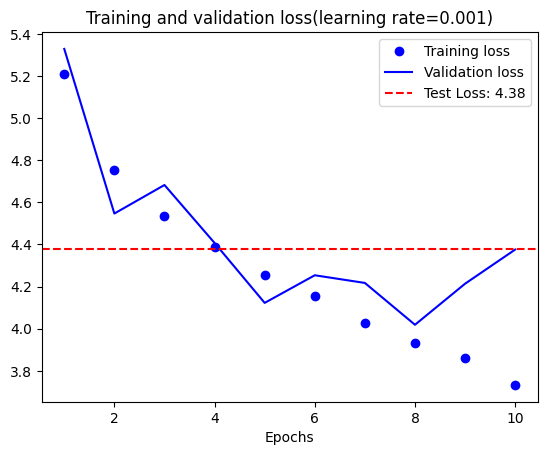

In [ ]:
#Grafici bontà di adattamento
history_dict = history.history

# Training and validation accuracy
acc_values = history_dict['accuracy']
epochs = range(1, len(acc_values) + 1)
val_acc_values = history_dict['val_accuracy']
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.axhline(y=test_acc, color='g', linestyle='--', label=f'Test Accuracy: {test_acc:.2f}')
plt.title('Training and validation accuracy(learning rate=0.001)')
plt.xlabel('Epochs')
plt.legend()
plt.show()

# Training and validation loss
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.axhline(y=test_loss, color='r', linestyle='--', label=f'Test Loss: {test_loss:.2f}')
plt.title('Training and validation loss(learning rate=0.001)')
plt.xlabel('Epochs')
plt.legend()
plt.show()

Modifica del learning rate da 0.001 a 0.0001 per ottenere una convergenza più stabile

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(optimizer=optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=['accuracy'])
model.summary()

history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_dataset
)

test_loss, test_acc=model.evaluate(test_dataset)
print('Test accuracy:', test_acc)

Il modello è accurato al ∼7%, meglio del precedente. Ma notiamo dal validation set che il modello sta overfittando sul training

In [ ]:
#Grafici bontà di adattamento
history_dict = history.history

# Training and validation accuracy
acc_values = history_dict['accuracy']
epochs = range(1, len(acc_values) + 1)
val_acc_values = history_dict['val_accuracy']
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.axhline(y=test_acc, color='g', linestyle='--', label=f'Test Accuracy: {test_acc:.2f}')
plt.title('Training and validation accuracy(learning rate=0.0001)')
plt.xlabel('Epochs')
plt.legend()
plt.show()

# Training and validation loss
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.axhline(y=test_loss, color='r', linestyle='--', label=f'Test Loss: {test_loss:.2f}')
plt.title('Training and validation loss(learning rate=0.0001)')
plt.xlabel('Epochs')
plt.legend()
plt.show()

Il modello inizia a overfittare dopo circa 4 epoche

# Early Stopping
Si sfrutta la callback "Early Stopping" per arrestare il modello preventivamente in modo tale da evitare l'overfitting; e la callback "Model Checkpoint" per salvare il modello migliore

In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu',padding="same",
                        input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu',padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu',padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu',padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())

model.add(layers.Dense(512, activation='relu'))

model.add(layers.Dense(120, activation='softmax'))

#TRAINING
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(optimizer=optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=['accuracy'])
model.summary()


early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                              patience=3,
                                              restore_best_weights = False)

checkpoint_filepath = 'checkpoint.model.keras'

checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_filepath,
                  monitor="val_accuracy", mode="max",
                  save_best_only=True, verbose=1)

history = model.fit(
  train_dataset,
  epochs=50,
  validation_data=validation_dataset,
  callbacks=[early_stop, checkpoint]
)

test_loss, test_acc=model.evaluate(test_dataset)
print('Test accuracy:', test_acc)
#GRAFICI BONTA' DI ADATTAMENTO

history_dict = history.history

# Training and validation accuracy
acc_values = history_dict['accuracy']
epochs = range(1, len(acc_values) + 1)
val_acc_values = history_dict['val_accuracy']
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.axhline(y=test_acc, color='g', linestyle='--', label=f'Test Accuracy: {test_acc:.2f}')
plt.title('Training and validation accuracy(learning rate=0.0001)')
plt.xlabel('Epochs')
plt.legend()
plt.show()

# Training and validation loss
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.axhline(y=test_loss, color='r', linestyle='--', label=f'Test Loss: {test_loss:.2f}')
plt.title('Training and validation loss(learning rate=0.0001)')
plt.xlabel('Epochs')
plt.legend()
plt.show()


#3) modello con Dropout


Si utilizza la tecnica di regolarizzazione del dropout, la quale "spegne" una percentuale definita di neuroni durante il training per prevenire l'overfitting

In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
                        input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))

model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.25))

model.add(layers.Dense(120, activation='softmax'))

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(optimizer=optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=['accuracy'])

history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset
)

test_loss, test_acc=model.evaluate(test_dataset)
print('Test accuracy:', test_acc)

Bontà di adattamento

In [ ]:
history_dict = history.history
history_dict.keys()

# Training and validation accuracy
acc_values = history_dict['accuracy']
epochs = range(1, len(acc_values) + 1)
val_acc_values = history_dict['val_accuracy']
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# # Training and validation loss
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

#4) Modello con Data Augmentation
Si sfrutta un' ulteriore tecnica per evitare l'overfitting, in questo caso ampliando il dataset del training, modificando i dati già esistenti per creare "nuove" variazioni delle osservazioni a ogni epoca

/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


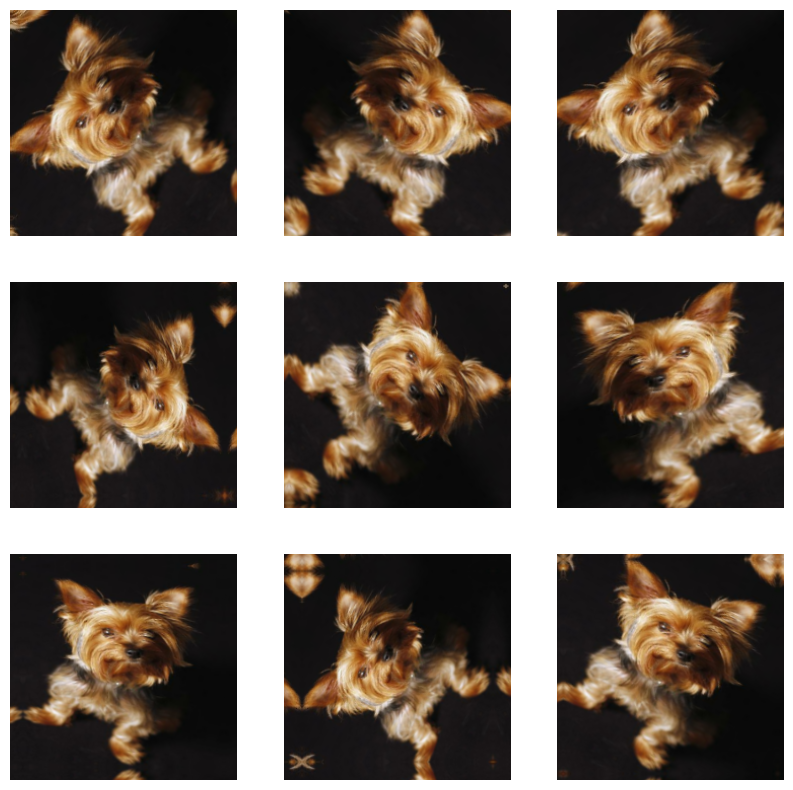

In [ ]:
# layer di data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal",
                               input_shape=(IMG_SIZE, IMG_SIZE, 3)), #flip orizz al 50%
    tf.keras.layers.RandomRotation(0.2), #rotation casuale tra 0 e 20 gradi
    tf.keras.layers.RandomZoom(0.2) #zoom casuale tra 0 e 20
])

# Visualizzazione
plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1): #prende un batch
    for i in range(9): #per ogni batch genera 9 immagini modificate
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1) #crea griglia
        plt.imshow(augmented_images[0]) #mostra la prima immagine aumentata
        plt.axis("off") #nasconde assi


In [ ]:
model = tf.keras.Sequential([

    data_augmentation, # layer di data augmentation

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu',padding="same",
                           input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.MaxPooling2D((2, 2))

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu',padding="same"),
    tf.keras.layers.MaxPooling2D((2, 2))

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu',padding="same"),
    tf.keras.layers.MaxPooling2D((2, 2))

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding="same"),
    tf.keras.layers.MaxPooling2D((2, 2))

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512, activation='relu'),

    tf.keras.layers.Dense(120, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(optimizer=optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                              patience=3,
                                              restore_best_weights = False)

checkpoint_filepath = 'checkpoint.model.keras'

checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_filepath,
                  monitor="val_accuracy", mode="max",
                  save_best_only=True, verbose=1)

history = model.fit(
  train_dataset,
  epochs=50,
  validation_data=validation_dataset,
  callbacks=[early_stop, checkpoint]
)

test_loss, test_acc=model.evaluate(test_dataset)
print('Test accuracy:', test_acc)

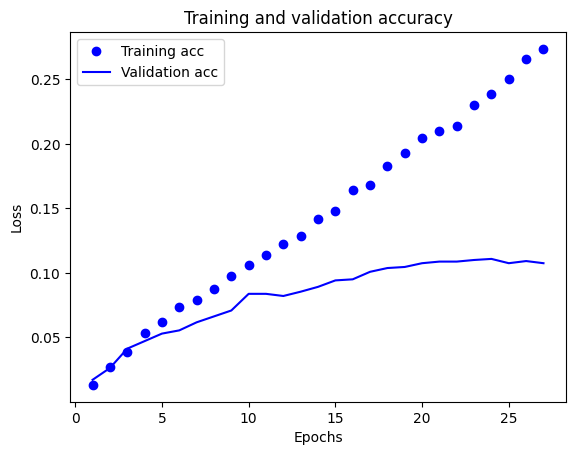

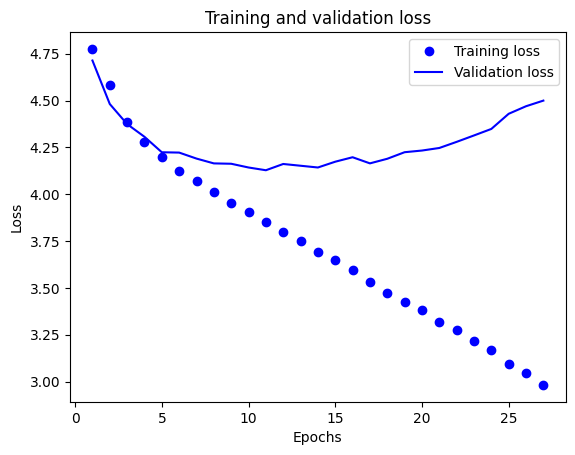

In [ ]:
history_dict = history.history
history_dict.keys()

# Training and validation accuracy
acc_values = history_dict['accuracy']
epochs = range(1, len(acc_values) + 1)
val_acc_values = history_dict['val_accuracy']
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show()

# Training and validation loss
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.legend()
plt.show()

# Hyper tuning
Si cercano i parametri ottimali della rete

In [ ]:
def model_builder(hp):
  model = tf.keras.Sequential()

  # Layer di data augmentation
  model.add(data_augmentation)

  # Tune il numero di filtri nei layer convoluzionali
  hp_filters_1 = hp.Int('filters_1', min_value=32, max_value=64, step=32)
  hp_filters_2 = hp.Int('filters_2', min_value=64, max_value=128, step=64)
  hp_filters_3 = hp.Int('filters_3', min_value=128, max_value=256, step=128)
  hp_filters_4 = hp.Int('filters_4', min_value=128, max_value=512, step=128)

  # Primo strato convoluzionale
  model.add(tf.keras.layers.Conv2D(hp_filters_1, (3, 3), activation='relu',
                                   input_shape=(IMG_SIZE, IMG_SIZE, 3)))
  model.add(tf.keras.layers.MaxPooling2D((2, 2)))
  model.add(tf.keras.layers.Dropout(rate = hp.Float('dropout_1', min_value = 0.1, max_value = 0.3, step = 0.1)))

  # Secondo strato convoluzionale
  model.add(tf.keras.layers.Conv2D(hp_filters_2, (3, 3), activation='relu', padding="same"))
  model.add(tf.keras.layers.MaxPooling2D((2, 2)))
  model.add(tf.keras.layers.Dropout(rate=hp.Float('dropout_2', min_value=0.1, max_value=0.3, step=0.1)))

  # Terzo strato convoluzionale
  model.add(tf.keras.layers.Conv2D(hp_filters_3, (3, 3), activation='relu', padding="same"))
  model.add(tf.keras.layers.MaxPooling2D((2, 2)))
  model.add(tf.keras.layers.Dropout(rate=hp.Float('dropout_3', min_value=0.1, max_value=0.3, step=0.1)))

  # Quarto strato convoluzionale
  model.add(tf.keras.layers.Conv2D(hp_filters_4, (3, 3), activation='relu', padding="same"))
  model.add(tf.keras.layers.MaxPooling2D((2, 2)))
  model.add(tf.keras.layers.Dropout(rate=hp.Float('dropout_4', min_value=0.2, max_value=0.5, step=0.1)))

  # Appiattisci
  model.add(tf.keras.layers.Flatten())

  # Primo strato denso
  model.add(tf.keras.layers.Dense(hp.Int('dense_units', min_value=256, max_value=2048, step=256), activation='relu'))
  model.add(tf.keras.layers.Dropout(rate=hp.Float('dropout_d', min_value=0.2, max_value=0.5, step=0.1)))

  # Strato di output
  model.add(tf.keras.layers.Dense(120, activation='softmax'))

  # Tune di apprendimento
  hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

  return model

In [ ]:
tuner = kt.Hyperband(model_builder,
                     objective='val_accuracy',
                     max_epochs=10,
                     factor=3)

In [ ]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

In [ ]:
tuner.search(train_dataset,
             epochs=10,
             validation_data=validation_dataset,
             callbacks=[stop_early])

# Ottiene gli iperparametri migliori
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]

In [ ]:
model = tuner.hypermodel.build(best_hps)
history = model.fit(train_dataset, epochs=50, validation_data=validation_dataset)

val_acc_per_epoch = history.history['val_accuracy']
best_epoch = val_acc_per_epoch.index(max(val_acc_per_epoch)) + 1
print('Best epoch: %d' % (best_epoch,))

In [ ]:
hypermodel = tuner.hypermodel.build(best_hps)

# Riallena il modello
hypermodel.fit(train_dataset, epochs=best_epoch, validation_data=validation_dataset)

In [ ]:
eval_result = hypermodel.evaluate(test_dataset)
print("[test loss, test accuracy]:", eval_result)

#5) Modello finale
Si prova a complicare ulteriormente l'architettura della rete neurale combinando diverse tecniche di regolarizzazione, con l'aggiunta della Batch Normalization.

In [ ]:
model = tf.keras.Sequential([
    data_augmentation,

    # Primo strato convoluzionale
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding="same",
                           input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.1),

    # Secondo strato convoluzionale
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.1),

    # Terzo strato convoluzionale
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.1),

    # Quarto strato convoluzionale
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.2),

    # Quinto strato convoluzionale
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.2),

    # Appiattisci
    tf.keras.layers.Flatten(),

    # Primo strato denso
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    # Secondo strato denso
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    # Strato di output
    tf.keras.layers.Dense(120, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005) #Learning rate modificato a 0.0005

model.compile(optimizer=optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                              patience=4,
                                              restore_best_weights = False)

checkpoint_filepath = 'checkpoint.model.keras'

checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_filepath,
                  monitor="val_accuracy", mode="max",
                  save_best_only=True, verbose=1)

history = model.fit(
  train_dataset,
  epochs=100,
  validation_data=validation_dataset,
  callbacks=[early_stop, checkpoint]
)

test_loss, test_acc=model.evaluate(test_dataset)
print('Test accuracy:', test_acc)

NameError: name 'validation_dataset' is not defined

Grafici Bontà di adattamento

In [ ]:
history_dict = history.history
history_dict.keys()

# Training and validation accuracy
acc_values = history_dict['accuracy']
epochs = range(1, len(acc_values) + 1)
val_acc_values = history_dict['val_accuracy']
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show()

# Training and validation loss
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.legend()
plt.show()

#PREVISIONI SUL TEST SET

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


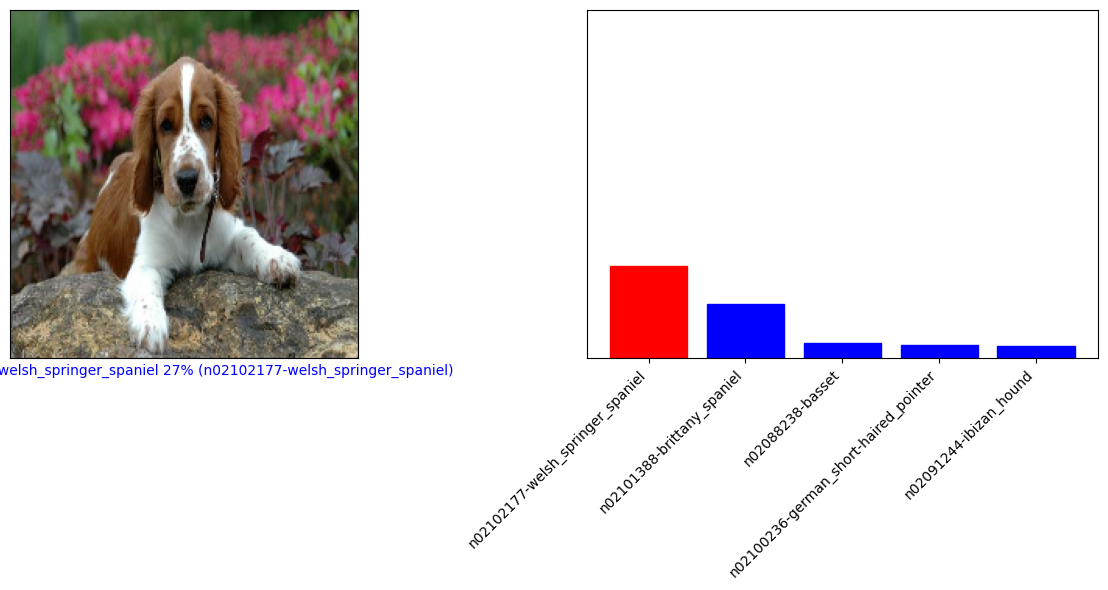

In [ ]:
# Liste per immagini e etichette
test_images = []
test_labels = []

# Estrai le immagini dal dataset e le ridimensiona
for image, label in test.take(10):  # Prende 10 immagini per test
    image = tf.image.resize(image, (224, 224))  # IMG_SIZE = 224
    image = image.numpy().astype("float32") / 255.0  # Normalizza tra 0 e 1
    test_images.append(image)
    test_labels.append(label.numpy())

# Converti in array NumPy
test_images = np.array(test_images)
test_labels = np.array(test_labels)

# Carica i nomi delle classi
class_names = info.features['label'].names

# Funzione per visualizzare l'immagine e la predizione
def plot_image(i, predictions_array, true_label, img, class_names):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img)

    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'

    plt.xlabel(f"{class_names[predicted_label]} {100 * np.max(predictions_array):2.0f}% ({class_names[true_label]})", color=color)

# Funzione per visualizzare il grafico a barre delle predizioni
def plot_value_array(i, predictions_array, true_label, class_names, top_n=5):
    true_label = true_label[i]

    # Trova gli indici delle top N classi con la probabilità più alta
    top_indices = np.argsort(predictions_array)[-top_n:][::-1]  # Ordina in ordine decrescente

    plt.grid(False)
    plt.xticks(range(top_n), [class_names[j] for j in top_indices], rotation=45, ha="right")
    plt.yticks([])

    # Mostra solo le top N classi
    top_predictions = predictions_array[top_indices]
    thisplot = plt.bar(range(top_n), top_predictions, color="#777777")
    plt.ylim([0, 1])

    predicted_label = top_indices[0]  # La classe con probabilità più alta
    for j in range(top_n):
        color = 'red' if top_indices[j] == predicted_label else 'blue'
        thisplot[j].set_color(color)


# Predizioni del modello
predictions = model.predict(test_images)

# Esempio di visualizzazione
i = 0  # Indice dell'immagine da visualizzare
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plot_image(i, predictions[i], test_labels, test_images, class_names)
plt.subplot(1, 2, 2)
plot_value_array(i, predictions[i], test_labels, class_names)
plt.tight_layout()
plt.show()
